# Sex and Nudity Detection


Fine-tunes **XLM-RoBERTa large** for 3-class ordinal classification of sex/nudity in literary passages: **absent** (0) · **weak** (1) · **strong** (2).

Stack: PyTorch · HuggingFace Transformers · HuggingFace `Trainer` API

Key design decisions:
- XLM-RoBERTa large: state-of-the-art multilingual encoder, far stronger than USE-CMLM
- Stratified 80/20 train/val split with fixed seed for reproducibility
- Balanced class weights in a custom loss to handle label imbalance
- Linear warm-up + linear decay learning rate schedule (standard for fine-tuning)
- Label smoothing to reflect ordinal ambiguity between adjacent classes
- Early stopping on macro F1 (not loss) so minority classes drive convergence
- Gradient accumulation to simulate larger batch sizes on limited GPU memory


## 1 · Install dependencies

In [ ]:
import os

In [ ]:
os.environ['HF_HOME'] = ('/Users/.../hf_cache')

In [ ]:
# Run once; restart the kernel afterwards if installing for the first time.
#!pip install transformers datasets accelerate scikit-learn openpyxl


## 2 · Imports & constants

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    mean_absolute_error, classification_report, confusion_matrix,
)

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

SEED        = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

MODEL_NAME  = 'xlm-roberta-large'
CLASS_NAMES = ['absent', 'weak', 'strong']
LABEL_MAP   = {'absent': 0, 'weak': 1, 'strong': 2}
NUM_CLASSES = 3
MAX_LEN     = 128   # tokens; increase to 256 for very long passages
BATCH_SIZE  = 8     # per-device batch size; use gradient accumulation below
GRAD_ACCUM  = 4     # effective batch = BATCH_SIZE * GRAD_ACCUM = 32
N_EPOCHS    = 20
LR          = 1e-5  # conservative LR for a large model on a small dataset
LABEL_SMOOTH = 0.1

TRAIN_PATH  = ('/Users/.../Training_Sex_Nudity2.xlsx')
TEST_PATH   = ('/Users/.../Test_Sex_Nudity.xlsx')
SAVE_PATH   = os.path.expanduser('~/model_nudity_xlmr')
PLOT_PATH   = ('/Users/.../ClassificationSuccess_Nudity2.pdf')

DEVICE = 'cuda' if torch.cuda.is_available() else \
         'mps'  if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
print(f'Model: {MODEL_NAME}')


Using device: mps
Model: xlm-roberta-large


## 3 · Load & inspect training data

In [ ]:
df = pd.read_excel(TRAIN_PATH)
df['label'] = df['tag'].map(LABEL_MAP)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print(f'Training set: {len(df)} passages')
counts = df['label'].value_counts().sort_index()
for idx, cnt in counts.items():
    print(f'  {CLASS_NAMES[idx]:8s}: {cnt:4d}  ({cnt/len(df)*100:.1f}%)')


Training set: 250 passages
  absent  :   82  (32.8%)
  weak    :   83  (33.2%)
  strong  :   85  (34.0%)


In [ ]:
df.head()


,passage,tag,label
0,December 1969 - Cambridge\n\nThere was a bitin...,absent,0
1,"Not by the majority of Boston, however. Songs ...",absent,0
2,December 1969 - New York\n\nSOMETIMES THE MAN ...,absent,0
3,Chapter 1\n\nWith an almost detached glance Ra...,absent,0
4,"By the end of the day, for the first time in m...",absent,0


## 4 · Stratified train / validation split

In [ ]:
texts  = df['passage'].astype(str).values
labels = df['label'].values

x_train, x_val, y_train, y_val = train_test_split(
    texts, labels,
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)
print(f'Train: {len(x_train)}   Val: {len(x_val)}')


Train: 200   Val: 50


## 5 · Balanced class weights

In [ ]:
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=labels
)
class_weights = torch.tensor(raw_weights, dtype=torch.float).to(DEVICE)
for k, v in enumerate(raw_weights):
    print(f'  {CLASS_NAMES[k]:8s}: weight = {v:.3f}')


  absent  : weight = 1.016
  weak    : weight = 1.004
  strong  : weight = 0.980


## 6 · Tokeniser & PyTorch Dataset

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class PassageDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

train_dataset = PassageDataset(x_train, y_train, tokenizer, MAX_LEN)
val_dataset   = PassageDataset(x_val,   y_val,   tokenizer, MAX_LEN)
print(f'Train dataset: {len(train_dataset)} samples')
print(f'Val dataset:   {len(val_dataset)} samples')


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train dataset: 200 samples
Val dataset:   50 samples


## 7 · Load XLM-RoBERTa large

In [ ]:
#!pip install hf_xet

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    # Initialise output layer with small weights for stable early training
    classifier_dropout=0.1,
)
model = model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {total/1e6:.1f}M total, {trainable/1e6:.1f}M trainable')


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parameters: 559.9M total, 559.9M trainable


## 8 · Custom Trainer with weighted + label-smoothed loss

In [ ]:
class WeightedLabelSmoothedTrainer(Trainer):
    """
    Overrides the default cross-entropy loss with:
    - Per-class weights  → counteracts class imbalance
    - Label smoothing    → softens one-hot targets; well-suited
                           to ordinal classes with fuzzy boundaries
    """
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits

        # Label smoothing: spread epsilon across all classes
        n = NUM_CLASSES
        eps = LABEL_SMOOTH
        one_hot = torch.zeros_like(logits).scatter_(1, labels.unsqueeze(1), 1)
        smooth_targets = one_hot * (1 - eps) + eps / n

        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        # Weight each sample by its class weight
        sample_weights = class_weights[labels]
        loss_per_sample = -(smooth_targets * log_probs).sum(dim=-1)
        loss = (loss_per_sample * sample_weights).mean()

        return (loss, outputs) if return_outputs else loss


## 9 · Evaluation metrics

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy':  accuracy_score(labels, preds),
        'macro_f1':  f1_score(labels, preds, average='macro',    zero_division=0),
        'kappa':     cohen_kappa_score(labels, preds),
        'kappa_lin': cohen_kappa_score(labels, preds, weights='linear'),
        'kappa_quad':cohen_kappa_score(labels, preds, weights='quadratic'),
        'mae':       mean_absolute_error(labels, preds),
    }


## 10 · Training arguments

In [ ]:
training_args = TrainingArguments(
    output_dir=SAVE_PATH,
    num_train_epochs=N_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,   # effective batch size = 32

    # Learning rate: linear warm-up over first 10% of steps, then linear decay
    learning_rate=LR,
    lr_scheduler_type='linear',
    warmup_ratio=0.10,
    weight_decay=0.01,                         # L2 regularisation on non-bias params

    # Evaluation & checkpointing
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',          # optimise for balanced performance
    greater_is_better=True,

    # Stability & speed
    fp16=torch.cuda.is_available(),            # mixed precision on GPU only
    dataloader_num_workers=0,
    seed=SEED,
    logging_steps=10,
    report_to='none',                          # disable wandb/tensorboard
)


## 11 · Train

In [ ]:
trainer = WeightedLabelSmoothedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=5,         # epochs without improvement on macro F1
        )
    ],
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Kappa,Kappa Lin,Kappa Quad,Mae
1,No log,1.084905,0.440000,0.340981,0.172088,0.120603,0.074564,0.840000
2,4.111200,1.014189,0.440000,0.333816,0.155100,0.208604,0.252084,0.780000
3,3.865600,0.955335,0.640000,0.525410,0.460432,0.617860,0.745269,0.380000
4,3.865600,0.887763,0.780000,0.778533,0.671249,0.734043,0.795441,0.240000
5,3.187900,0.791859,0.780000,0.781426,0.670856,0.729730,0.789030,0.240000
6,2.951100,0.691011,0.780000,0.781213,0.671053,0.733807,0.795202,0.240000
7,2.951100,0.663879,0.800000,0.805336,0.699880,0.767008,0.839021,0.200000
8,2.276800,0.631375,0.820000,0.819601,0.730700,0.798748,0.866310,0.180000
9,2.028800,0.650854,0.800000,0.802317,0.700419,0.771062,0.844431,0.200000
10,1.653600,0.647182,0.840000,0.838222,0.759904,0.797844,0.835625,0.180000


TrainOutput(global_step=105, training_loss=2.3996298926217214, metrics={'train_runtime': 382.1181, 'train_samples_per_second': 10.468, 'train_steps_per_second': 0.314, 'total_flos': 698950884096000.0, 'train_loss': 2.3996298926217214, 'epoch': 15.0})

## 12 · Training curves

In [3]:
log_history = trainer.state.log_history

# Separate train-step logs and per-epoch eval logs
train_logs = [l for l in log_history if 'loss' in l and 'eval_loss' not in l]
eval_logs  = [l for l in log_history if 'eval_loss' in l]

if eval_logs:
    epochs   = [l['epoch']          for l in eval_logs]
    val_f1   = [l.get('eval_macro_f1',   0) for l in eval_logs]
    val_acc  = [l.get('eval_accuracy',   0) for l in eval_logs]
    val_loss = [l.get('eval_loss',       0) for l in eval_logs]
    val_kappa= [l.get('eval_kappa',      0) for l in eval_logs]

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    for ax, vals, title in zip(
        axes,
        [val_loss, val_acc, val_f1, val_kappa],
        ['Val Loss', 'Val Accuracy', 'Val Macro F1', "Val Cohen's Kappa"]
    ):
        ax.plot(epochs, vals, marker='o')
        ax.set_title(title, fontsize=16)
        ax.set_xlabel('epoch', fontsize=12)

    fig.tight_layout()
    fig.savefig(PLOT_PATH)
    plt.show()
    print(f'Plot saved to {PLOT_PATH}')



## 13 · Evaluation helpers

In [ ]:
def full_evaluate(texts, true_labels, title='Results'):
    """Run inference and print a complete metrics report + confusion matrix."""
    dataset = PassageDataset(texts, true_labels, tokenizer, MAX_LEN)
    preds_out = trainer.predict(dataset)
    pred_labels = np.argmax(preds_out.predictions, axis=1)

    print(f'=== {title} ===')
    print(f'Accuracy:          {accuracy_score(true_labels, pred_labels):.4f}')
    print(f'Macro F1:          {f1_score(true_labels, pred_labels, average="macro"):.4f}')
    print(f'Weighted F1:       {f1_score(true_labels, pred_labels, average="weighted"):.4f}')
    print(f'Cohen\'s Kappa:     {cohen_kappa_score(true_labels, pred_labels):.4f}')
    print(f'Kappa (linear):    {cohen_kappa_score(true_labels, pred_labels, weights="linear"):.4f}')
    print(f'Kappa (quadratic): {cohen_kappa_score(true_labels, pred_labels, weights="quadratic"):.4f}')
    print(f'MAE:               {mean_absolute_error(true_labels, pred_labels):.4f}')
    print()
    print(classification_report(true_labels, pred_labels, target_names=CLASS_NAMES))

    cm = confusion_matrix(true_labels, pred_labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set(xticks=range(NUM_CLASSES), yticks=range(NUM_CLASSES),
           xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
           xlabel='Predicted label', ylabel='True label',
           title=f'Confusion Matrix – {title}')
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.show()
    return pred_labels


## 14 · Evaluate on validation set

=== Validation Set ===
Accuracy:          0.8400
Macro F1:          0.8382
Weighted F1:       0.8387
Cohen's Kappa:     0.7599
Kappa (linear):    0.7978
Kappa (quadratic): 0.8356
MAE:               0.1800

              precision    recall  f1-score   support

      absent       0.81      0.81      0.81        16
        weak       0.81      0.76      0.79        17
      strong       0.89      0.94      0.91        17

    accuracy                           0.84        50
   macro avg       0.84      0.84      0.84        50
weighted avg       0.84      0.84      0.84        50


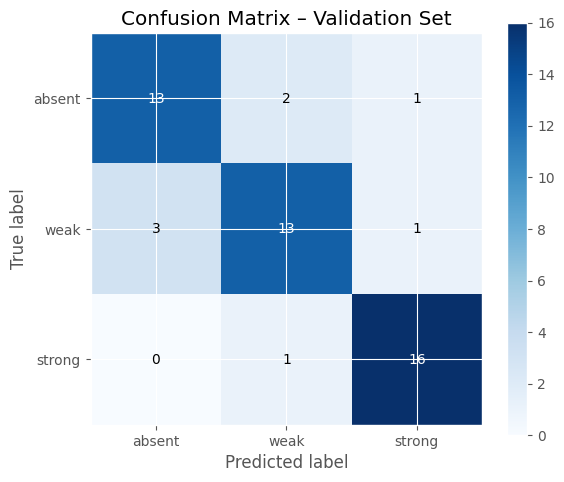

In [ ]:
_ = full_evaluate(x_val, y_val, title='Validation Set')


## 15 · Evaluate on external test set

External test set: 30 passages
tag
absent    17
weak      10
strong     3
Name: count, dtype: int64


=== External Test Set ===
Accuracy:          0.7000
Macro F1:          0.6317
Weighted F1:       0.6629
Cohen's Kappa:     0.4130
Kappa (linear):    0.4828
Kappa (quadratic): 0.5610
MAE:               0.3333

              precision    recall  f1-score   support

      absent       0.70      0.94      0.80        17
        weak       0.75      0.30      0.43        10
      strong       0.67      0.67      0.67         3

    accuracy                           0.70        30
   macro avg       0.70      0.64      0.63        30
weighted avg       0.71      0.70      0.66        30


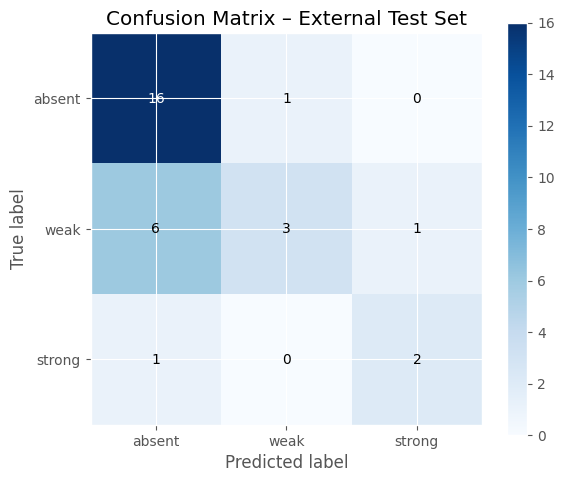

In [ ]:
df_test = pd.read_excel(TEST_PATH)
df_test['label'] = df_test['tag'].map(LABEL_MAP)
unknown = df_test['label'].isna().sum()
if unknown > 0:
    print(f'Warning: {unknown} rows with unrecognised tags dropped.')
    df_test = df_test.dropna(subset=['label'])
df_test['label'] = df_test['label'].astype(int)

print(f'External test set: {len(df_test)} passages')
print(df_test['tag'].value_counts())

x_ext      = df_test['passage'].astype(str).values
y_ext_true = df_test['label'].values

_ = full_evaluate(x_ext, y_ext_true, title='External Test Set')


## 16 · Save model & tokeniser

In [2]:
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f'Model and tokeniser saved to: {SAVE_PATH}')


## 17 · Load model & run inference on new passages

In [ ]:
from transformers import pipeline

# The pipeline handles tokenisation and softmax automatically.
# id2label lets it return human-readable class names.
id2label = {i: name for i, name in enumerate(CLASS_NAMES)}
label2id = {name: i for i, name in enumerate(CLASS_NAMES)}

clf = pipeline(
    'text-classification',
    model=SAVE_PATH,
    tokenizer=SAVE_PATH,
    device=0 if DEVICE == 'cuda' else -1,
    top_k=None,          # return probabilities for all classes
)

new_passages = [
    'The knight drew his sword and charged at the enemy.',
    'She walked quietly through the moonlit garden.',
    'The battle was brutal; bodies lay scattered across the field.',
]

for passage in new_passages:
    scores = {r['label']: r['score'] for r in clf(passage)[0]}
    pred   = max(scores, key=scores.get)
    print(f'Passage : {passage}')
    print(f'Predicted: {pred}  '
          f'(absent={scores.get("LABEL_0", scores.get("absent",0)):.2f}, '
          f'weak={scores.get("LABEL_1", scores.get("weak",0)):.2f}, '
          f'strong={scores.get("LABEL_2", scores.get("strong",0)):.2f})')
    print()


Device set to use cpu


Passage : The knight drew his sword and charged at the enemy.
Predicted: LABEL_0  (absent=0.69, weak=0.19, strong=0.12)

Passage : She walked quietly through the moonlit garden.
Predicted: LABEL_0  (absent=0.73, weak=0.16, strong=0.10)

Passage : The battle was brutal; bodies lay scattered across the field.
Predicted: LABEL_0  (absent=0.72, weak=0.18, strong=0.10)


In [ ]:
import xml.etree.ElementTree as ET
import re
from collections import Counter
from transformers import pipeline

# ── Configuration ─────────────────────────────────────────────────────────────
TEI_PATH   = '/Users/.../gold_annotations_test/Erotic_Scenes_in_MMiA.xml'
MAX_CHARS  = 1500   # ~512 tokens; adjust if you see truncation warnings

# ── Helpers ───────────────────────────────────────────────────────────────────
NS = {'tei': 'http://www.tei-c.org/ns/1.0'}

def clean(text):
    return re.sub(r'\s+', ' ', text).strip()

def get_text(element):
    return clean(' '.join(element.itertext()))

def split_into_chunks(text, max_chars):
    """
    Split text into chunks of at most max_chars, breaking only at sentence
    boundaries ('. ', '! ', '? '). If a single sentence exceeds max_chars
    it is kept as one chunk rather than cut mid-word.
    Returns a list of (chunk_index, chunk_text) tuples.
    """
    # Split at sentence-ending punctuation followed by a space
    sentences = re.split(r'(?<=[.!?])\s+', text)
    chunks, current = [], []
    current_len = 0

    for sentence in sentences:
        if current and current_len + len(sentence) > max_chars:
            chunks.append(' '.join(current))
            current, current_len = [], 0
        current.append(sentence)
        current_len += len(sentence) + 1

    if current:
        chunks.append(' '.join(current))

    return [(i + 1, chunk) for i, chunk in enumerate(chunks)]

def majority_vote(predictions):
    """
    Return the most frequent label. In case of a tie, prefer the
    more severe label (strong > weak > absent).
    """
    count    = Counter(predictions)
    max_freq = max(count.values())
    tied     = [label for label, freq in count.items() if freq == max_freq]
    severity = ['absent', 'weak', 'strong']
    return max(tied, key=lambda l: severity.index(l))

def classify(clf, text):
    """Run classifier and return normalised score dict + predicted label."""
    scores_raw = {r['label']: r['score'] for r in clf(text)[0]}
    scores = {
        'absent': scores_raw.get('absent', scores_raw.get('LABEL_0', 0)),
        'weak':   scores_raw.get('weak',   scores_raw.get('LABEL_1', 0)),
        'strong': scores_raw.get('strong', scores_raw.get('LABEL_2', 0)),
    }
    return scores, max(scores, key=scores.get)

# ── Parse TEI ─────────────────────────────────────────────────────────────────
tree = ET.parse(TEI_PATH)
root = tree.getroot()

scenes = root.findall('.//tei:scene', NS)
if scenes:
    segments = [{'type': 'scene',   'n': s.get('n', '?'), 'text': get_text(s)}
                for s in scenes]
else:
    body, segments = root.find('.//tei:body', NS), []
    current_chapter, current_parts = None, []
    for child in body.iter():
        if child.tag == f'{{{NS["tei"]}}}chapter':
            if current_chapter is not None:
                segments.append({'type': 'chapter', 'n': current_chapter,
                                  'text': clean(' '.join(current_parts))})
            current_chapter, current_parts = child.get('n', '?'), []
        else:
            t = (child.text or '') + (child.tail or '')
            if t.strip():
                current_parts.append(t.strip())
    if current_chapter and current_parts:
        segments.append({'type': 'chapter', 'n': current_chapter,
                          'text': clean(' '.join(current_parts))})

print(f'Found {len(segments)} segment(s).')

# ── Load classifier ────────────────────────────────────────────────────────────
clf = pipeline(
    'text-classification',
    model=SAVE_PATH,
    tokenizer=SAVE_PATH,
    device=0 if DEVICE == 'cuda' else -1,
    top_k=None,
)

# ── Classify with chunking + majority vote ─────────────────────────────────────
results = []

for seg in segments:
    seg_label = f'{seg["type"].capitalize()} {seg["n"]}'
    chunks    = split_into_chunks(seg['text'], MAX_CHARS)
    needs_split = len(chunks) > 1

    print(f'── {seg_label}  ({len(seg["text"])} chars → {len(chunks)} chunk(s)) ──')

    chunk_results = []
    for chunk_idx, chunk_text in chunks:
        chunk_id = f'{seg["type"]}_{seg["n"]}_chunk_{chunk_idx}'
        scores, pred = classify(clf, chunk_text)
        chunk_results.append({'chunk_id': chunk_id, 'prediction': pred,
                               'scores': scores, 'text': chunk_text})
        if needs_split:
            print(f'  [{chunk_id}]  → {pred}  '
                  f'(absent={scores["absent"]:.2f}  '
                  f'weak={scores["weak"]:.2f}  '
                  f'strong={scores["strong"]:.2f})')
            print(f'    {chunk_text[:100]}...')

    # Majority vote over all chunks
    final_pred = majority_vote([c['prediction'] for c in chunk_results])

    # Average scores across chunks for a summary probability
    avg_scores = {
        cls: sum(c['scores'][cls] for c in chunk_results) / len(chunk_results)
        for cls in ['absent', 'weak', 'strong']
    }

    results.append({
        'segment':    seg_label,
        'type':       seg['type'],
        'n':          seg['n'],
        'n_chunks':   len(chunks),
        'chunks':     chunk_results,
        'prediction': final_pred,
        **{f'avg_{k}': v for k, v in avg_scores.items()},
    })

    print(f'  ➜ Final ({len(chunks)} chunk(s), majority vote): {final_pred}  '
          f'(avg absent={avg_scores["absent"]:.2f}  '
          f'weak={avg_scores["weak"]:.2f}  '
          f'strong={avg_scores["strong"]:.2f})')
    print()

# ── Summary table ──────────────────────────────────────────────────────────────
import pandas as pd
df_results = pd.DataFrame([{
    'segment':    r['segment'],
    'n_chunks':   r['n_chunks'],
    'prediction': r['prediction'],
    'avg_absent': round(r['avg_absent'], 3),
    'avg_weak':   round(r['avg_weak'],   3),
    'avg_strong': round(r['avg_strong'], 3),
} for r in results])

print('\n=== Summary ===')
print(df_results.to_string(index=False))

'''

The output for a long scene will look like this:
```
── Scene 1  (3421 chars → 3 chunk(s)) ──
  [scene_1_chunk_1]  → absent  (absent=0.71  weak=0.21  strong=0.08)
    The sunlight was brilliant, making Leah squint as she walked...
  [scene_1_chunk_2]  → weak    (absent=0.31  weak=0.54  strong=0.15)
    Groaning inwardly, she shoved all her fears, anxieties...
  [scene_1_chunk_3]  → weak    (absent=0.28  weak=0.49  strong=0.23)
    Anders came in the other door, his leathery face devoid...
  ➜ Final (3 chunks, majority vote): weak  (avg absent=0.43  weak=0.41  strong=0.15)'''

Found 11 segment(s).


Device set to use cpu


── Scene 81  (5651 chars → 4 chunk(s)) ──
  [scene_81_chunk_1]  → strong  (absent=0.03  weak=0.13  strong=0.84)
    He didn't release her until they reached his bedroom. Kicking the door shut behind them, he slowly l...
  [scene_81_chunk_2]  → strong  (absent=0.04  weak=0.16  strong=0.80)
    His clever, sensitive hands trailed down the taut skin of her stomach to rest lightly on the elastic...
  [scene_81_chunk_3]  → strong  (absent=0.03  weak=0.16  strong=0.80)
    She kissed his thighs, his knees, his calves, his feet, reveling in the salt-sea taste of him, the r...
  [scene_81_chunk_4]  → weak  (absent=0.14  weak=0.53  strong=0.33)
    And then he did move, beginning the sweet, slow rhythm of love, the ebb and flow as timeless as the ...
  ➜ Final (4 chunk(s), majority vote): strong  (avg absent=0.06  weak=0.25  strong=0.69)

── Scene 22  (5387 chars → 4 chunk(s)) ──
  [scene_22_chunk_1]  → strong  (absent=0.04  weak=0.20  strong=0.75)
    The transition from friends to lovers took

'\n\nThe output for a long scene will look like this:\n```\n── Scene 1  (3421 chars → 3 chunk(s)) ──\n  [scene_1_chunk_1]  → absent  (absent=0.71  weak=0.21  strong=0.08)\n    The sunlight was brilliant, making Leah squint as she walked...\n  [scene_1_chunk_2]  → weak    (absent=0.31  weak=0.54  strong=0.15)\n    Groaning inwardly, she shoved all her fears, anxieties...\n  [scene_1_chunk_3]  → weak    (absent=0.28  weak=0.49  strong=0.23)\n    Anders came in the other door, his leathery face devoid...\n  ➜ Final (3 chunks, majority vote): weak  (avg absent=0.43  weak=0.41  strong=0.15)'